# Sentimiento por categoría

Con el sentimiento ya calculado sobre los 7,613 tweets, respondemos tres preguntas:

1. ¿Cuáles son los 10 tweets más negativos y en qué categoría están?
2. ¿Cuáles son los 10 tweets más positivos y en qué categoría están?
3. ¿Son los tweets de desastre real más negativos que los de la otra categoría?

Usamos el `compound` de VADER como medida de polaridad. A diferencia del conteo simple de
palabras, incorpora negación e intensificadores, y está acotado a [-1, 1], lo que permite
ordenar los tweets de un extremo al otro.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 90)

df = pd.read_csv('../data/cleaned/train_sentimiento.csv')
df['categoria'] = df['target'].map({0: 'No desastre', 1: 'Desastre real'})
print(f'{len(df)} tweets con sentimiento calculado')
print(f"compound entre {df['compound'].min():.4f} y {df['compound'].max():.4f}")

7613 tweets con sentimiento calculado
compound entre -0.9883 y 0.9730


## 1. Los 10 tweets más negativos

In [2]:
mas_negativos = df.nsmallest(10, 'compound')[['text', 'compound', 'categoria']]
display(mas_negativos.reset_index(drop=True))

print('Distribución por categoría:')
print(mas_negativos['categoria'].value_counts().to_string())

,text,compound,categoria
0,wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?,-0.9883,No desastre
1,@Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bomber targ...,-0.9686,Desastre real
2,Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed at lea...,-0.9623,Desastre real
3,? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; Blamed...,-0.9595,Desastre real
4,17 killed in SÛªArabia mosque suicide bombing\n\nA suicide bomber attacked a mosque i...,-0.9552,Desastre real
5,at the lake \n*sees a dead fish*\nme: poor little guy i wonder what happened\nashley: ...,-0.9549,No desastre
6,illegal alien released by Obama/DHS 4 times Charged With Rape &amp; Murder of Santa Ma...,-0.9538,Desastre real
7,Bomb Crash Loot Riot Emergency Pipe Bomb Nuclear Chemical Spill Gas Ricin Leak Violenc...,-0.9524,Desastre real
8,Bomb head? Explosive decisions dat produced more dead children than dead bodies trappe...,-0.9500,Desastre real
9,@cspan #Prez. Mr. President you are the biggest terrorist and trouble maker in the wor...,-0.9493,Desastre real


Distribución por categoría:
categoria
Desastre real    8
No desastre      2


**Ocho de los diez pertenecen a la categoría de desastre real.** Son atentados con
explosivos, tiroteos y ataques con víctimas mortales, redactados en registro noticioso, con
términos como `suicide bomber`, `killed` y `dead` acumulados en un mismo tweet.

Los dos que no son desastre merecen comentario:

- El **más negativo del corpus entero** (-0.9883) es `"wreck? wreck wreck wreck…"`, la
  palabra repetida trece veces. No describe nada: el `compound` se satura por acumulación de
  un mismo término negativo. Es un artefacto del método, no un tweet especialmente sombrío.
- El otro narra el hallazgo de un pez muerto en un lago en tono conversacional. Contiene
  `dead` y `poor`, suficiente para hundir la puntuación, pero es una anécdota casual.

Ambos ilustran el mismo límite: VADER suma valencias sin entender de qué se habla.

## 2. Los 10 tweets más positivos

In [3]:
mas_positivos = df.nlargest(10, 'compound')[['text', 'compound', 'categoria']]
display(mas_positivos.reset_index(drop=True))

print('Distribución por categoría:')
print(mas_positivos['categoria'].value_counts().to_string())

,text,compound,categoria
0,Check out 'Want Twister Tickets AND A VIP EXPERIENCE To See SHANIA? CLICK HERE:' at h...,0.9730,No desastre
1,@thoutaylorbrown I feel like accidents are just drawn to you but I'm happy you've surv...,0.9564,No desastre
2,TodayÛªs storm will pass; let tomorrowÛªs light greet you with a kiss. Bask in this ...,0.9471,Desastre real
3,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was inter...,0.9423,No desastre
4,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was inter...,0.9423,No desastre
5,Maaaaan I love Love Without Tragedy by @rihanna I wish she made the whole song,0.9394,No desastre
6,Free Ebay Sniping RT? http://t.co/B231Ul1O1K Lumbar Extender Back Stretcher Excellent ...,0.9376,No desastre
7,@Raishimi33 :) well I think that sounds like a fine plan where little derailment is po...,0.9356,Desastre real
8,I'm not a Drake fan but I enjoy seeing him body-bagging people. Great marketing lol.,0.9345,No desastre
9,@duchovbutt @Starbuck_Scully @MadMakNY @davidduchovny yeah we survived 9 seasons and 2...,0.9344,No desastre


Distribución por categoría:
categoria
No desastre      8
Desastre real    2


El reparto se invierte: **ocho de los diez son de la categoría no-desastre**, y son
promociones, conversación entre usuarios y entusiasmo por música o televisión.

Los dos etiquetados como desastre real son los interesantes, porque cuesta justificar la
etiqueta:

- `"Today's storm will pass; let tomorrow's light greet you with a kiss…"` usa `storm` como
  metáfora de consuelo. No informa de ningún desastre.
- `"…well I think that sounds like a fine plan where little derailment is possible"` usa
  `derailment` en sentido figurado dentro de una charla amistosa.

Los dos contienen vocabulario de desastre empleado metafóricamente, que es exactamente el
patrón que el clasificador del inciso 7 no logra distinguir. La diferencia es que aquí el
error no es del modelo sino de la etiqueta: el dataset los marca como desastre real y no lo
son. Da una idea del techo de exactitud alcanzable sobre estos datos.

## 3. ¿Son más negativos los tweets de desastre real?

In [4]:
resumen = df.groupby('categoria')['compound'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']).round(4)
display(resumen)

print('\nDistribución de etiquetas de sentimiento dentro de cada categoría (%):')
tabla = pd.crosstab(df['categoria'], df['etiqueta_vader'], normalize='index') * 100
display(tabla[['negativo', 'neutral', 'positivo']].round(1))

,count,mean,median,std,min,max
categoria,,,,,,
Desastre real,3271,-0.2667,-0.3182,0.4289,-0.9686,0.9471
No desastre,4342,-0.0611,0.0000,0.4582,-0.9883,0.9730



Distribución de etiquetas de sentimiento dentro de cada categoría (%):


etiqueta_vader,negativo,neutral,positivo
categoria,,,
Desastre real,57.1,26.8,16.1
No desastre,42.7,25.9,31.4


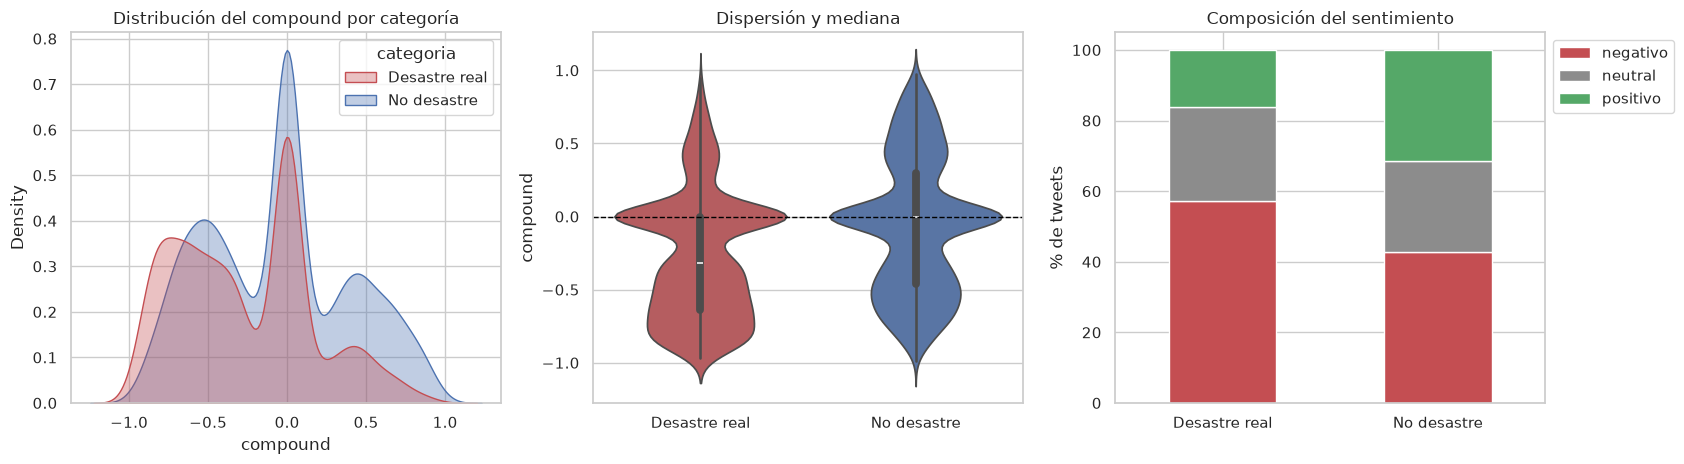

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
paleta = {'No desastre': '#4C72B0', 'Desastre real': '#C44E52'}

sns.kdeplot(data=df, x='compound', hue='categoria', fill=True, alpha=0.35,
            palette=paleta, ax=axes[0])
axes[0].set_title('Distribución del compound por categoría')
axes[0].set_xlabel('compound')

sns.violinplot(data=df, x='categoria', y='compound', hue='categoria',
               palette=paleta, legend=False, ax=axes[1])
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].set_title('Dispersión y mediana')
axes[1].set_xlabel('')

tabla[['negativo', 'neutral', 'positivo']].plot(
    kind='bar', stacked=True, ax=axes[2],
    color=['#C44E52', '#8C8C8C', '#55A868'])
axes[2].set_title('Composición del sentimiento')
axes[2].set_ylabel('% de tweets')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='', bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.show()

### Contraste estadístico

La distribución del `compound` es bimodal y está lejos de ser normal, así que la prueba
principal es **Mann-Whitney U**, que compara rangos y no supone normalidad. Añadimos la t de
Welch como referencia y dos medidas de tamaño de efecto, porque con más de 7,000
observaciones casi cualquier diferencia sale significativa y el p-valor por sí solo no dice
si la diferencia importa.

In [6]:
desastre = df[df['target'] == 1]['compound']
no_desastre = df[df['target'] == 0]['compound']

u, p_u = stats.mannwhitneyu(desastre, no_desastre, alternative='less')
t, p_t = stats.ttest_ind(desastre, no_desastre, equal_var=False)

n1, n0 = len(desastre), len(no_desastre)
rango_biserial = 1 - 2 * u / (n1 * n0)
s_pool = np.sqrt(((n1 - 1) * desastre.var() + (n0 - 1) * no_desastre.var()) / (n1 + n0 - 2))
cohen_d = (desastre.mean() - no_desastre.mean()) / s_pool

print(f'compound medio    desastre = {desastre.mean():+.4f}   no desastre = {no_desastre.mean():+.4f}')
print(f'mediana           desastre = {desastre.median():+.4f}   no desastre = {no_desastre.median():+.4f}')
print(f'\nMann-Whitney U (H1: desastre más negativo): U = {u:,.0f}, p = {p_u:.3e}')
print(f't de Welch: t = {t:.2f}, p = {p_t:.3e}')
print(f'\nTamaño de efecto:')
print(f'  correlación rango-biserial = {rango_biserial:.4f}')
print(f"  d de Cohen                 = {cohen_d:.4f}")

compound medio    desastre = -0.2667   no desastre = -0.0611
mediana           desastre = -0.3182   no desastre = +0.0000

Mann-Whitney U (H1: desastre más negativo): U = 5,324,822, p = 9.835e-80
t de Welch: t = -20.10, p = 1.693e-87

Tamaño de efecto:
  correlación rango-biserial = 0.2502
  d de Cohen                 = -0.4611


**Sí, los tweets de desastre real son más negativos, y la diferencia es sólida.**

El `compound` medio es -0.267 frente a -0.061. La mediana marca todavía mejor el contraste:
-0.318 en desastre contra 0.000 en no-desastre, es decir que el tweet típico de no-desastre
es neutro mientras que el típico de desastre ya carga negatividad. El 57.1% de los tweets de
desastre son negativos, contra el 42.7% de los otros, y la proporción de positivos casi se
duplica en sentido contrario (31.4% frente a 16.1%).

Mann-Whitney da p ≈ 1e-80, así que la diferencia no es casualidad de muestreo. La d de Cohen
de -0.46 la sitúa como **efecto mediano**: real y perfectamente utilizable, pero lejos de
separar las clases por sí sola.

Ese matiz es el que importa de cara al siguiente ejercicio. Que el 42.7% de los tweets
no-desastre también sean negativos significa que la negatividad no distingue un terremoto de
una queja sobre el tráfico o de una mala racha deportiva. Es una señal complementaria a la
del vocabulario, no un sustituto, y por eso conviene esperar del inciso 10 una mejora
moderada del clasificador antes que un salto.

## 4. Una observación sobre la calidad de los datos

Al revisar los tweets extremos aparecieron textos repetidos. Los contamos.

In [7]:
duplicados = df['text'].duplicated(keep=False)
etiquetas_por_texto = df[duplicados].groupby('text')['target'].nunique()
contradictorios = etiquetas_por_texto[etiquetas_por_texto > 1]

print(f'Tweets con texto repetido: {duplicados.sum()} ({duplicados.mean():.2%}) '
      f'en {df.loc[duplicados, "text"].nunique()} textos distintos')
print(f'Textos repetidos con etiquetas contradictorias: {len(contradictorios)}\n')

for texto in contradictorios.index[:3]:
    etiquetas = df[df['text'] == texto]['target'].tolist()
    print(f'  etiquetas {etiquetas}  ←  {texto[:78]}')

Tweets con texto repetido: 179 (2.35%) en 69 textos distintos
Textos repetidos con etiquetas contradictorias: 18

  etiquetas [0, 0, 1]  ←  #Allah describes piling up #wealth thinking it would last #forever as the desc
  etiquetas [1, 1, 0]  ←  #foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban uns
  etiquetas [1, 1, 0, 1]  ←  .POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internall


179 tweets aparecen repetidos, y en 18 casos el mismo texto exacto está etiquetado a la vez
como desastre y como no-desastre. Ningún modelo puede acertar en ambas copias: son un piso
de error irreducible.

Es una cantidad pequeña frente a 7,613 tweets, pero ayuda a interpretar el desempeño del
inciso 6. Parte del 19.5% de error del clasificador no proviene del modelo sino de
etiquetas inconsistentes y de casos genuinamente ambiguos como los dos "desastres positivos"
de la sección 2.

## 5. Conclusiones

- **Los 10 más negativos:** 8 de 10 son desastre real, principalmente atentados con víctimas
  mortales. Los 2 restantes exponen una debilidad del método: uno satura la puntuación
  repitiendo `wreck` trece veces y el otro es una anécdota casual sobre un pez muerto.
- **Los 10 más positivos:** 8 de 10 son no-desastre, sobre todo promociones y conversación.
  Los 2 etiquetados como desastre usan `storm` y `derailment` en sentido figurado y parecen
  estar mal etiquetados en el dataset original.
- **Sí, los tweets de desastre real son significativamente más negativos**: compound medio
  -0.267 contra -0.061, mediana -0.318 contra 0.000, Mann-Whitney p ≈ 1e-80 y d de Cohen de
  -0.46, un efecto mediano.
- El efecto es real pero no separa las clases por sí solo: el 42.7% de los tweets
  no-desastre también son negativos. La negatividad complementa al vocabulario en lugar de
  reemplazarlo.
- El dataset contiene 179 tweets repetidos, 18 de ellos con etiquetas contradictorias, lo
  que fija un piso de error que ningún clasificador puede cruzar.